In [1]:
import pandas as pd
from matplotlib import pyplot as plt

from pathlib import Path

from xaikd import constants

from glob import glob

import matplotlib as mpl

import numpy as np

from datetime import datetime

In [2]:
ARTIFACT_DIR = Path("./artifacts/experiments/perf-curve/run1")
ARTIFACT_DIR

PosixPath('artifacts/experiments/perf-curve/run1')

In [3]:
def load_data(model, layer, dataset_name, basis_name, verbose=False, data_size=1.0, ref_col="ref_auroc", stat_col="test_auroc"):
    path = ARTIFACT_DIR / model / dataset_name / f"data-size{data_size}" / layer / basis_name / "stats.csv"
    if verbose:
        print(f"path: {path}")

    files = sorted(list(glob(f"{path}")))
        
    
    if verbose:
        print(f"we have {len(files)} files")
    arr_dfs = [pd.read_csv(f) for f in files]
    
    df = pd.concat(arr_dfs)

    assert (df.arch.values == model).all()
    assert len(df.basis_name.unique()) == 1
    assert len(df.layer.unique()) == 1

    # return df
    
    df = df.groupby(["k"]).agg({
        ref_col: ["mean", "sem", "count"],
        stat_col: ["mean", "sem", "count"],
        "d": ["mean"]
    }).reset_index()
    
    return df
    
load_data("cifar100-resnet18-v1", "layer3", "cifar100-*-vs-others", "prcaposdef-with-weight-p1", verbose=True)

path: artifacts/experiments/perf-curve/run1/cifar100-resnet18-v1/cifar100-*-vs-others/data-size1.0/layer3/prcaposdef-with-weight-p1/stats.csv
we have 20 files


k ref_auroc                 test_auroc                      d
             mean       sem count       mean       sem count   mean
0     1  0.986878  0.001704    20   0.506645  0.003361    20  256.0
1     3  0.986878  0.001704    20   0.677050  0.028384    20  256.0
2     5  0.986878  0.001704    20   0.797968  0.026333    20  256.0
3     8  0.986878  0.001704    20   0.880731  0.013772    20  256.0
4    10  0.986878  0.001704    20   0.905913  0.010938    20  256.0
5    13  0.986878  0.001704    20   0.935975  0.008263    20  256.0
6    15  0.986878  0.001704    20   0.949107  0.006927    20  256.0
7    18  0.986878  0.001704    20   0.962384  0.004932    20  256.0
8    20  0.986878  0.001704    20   0.969103  0.004024    20  256.0
9    23  0.986878  0.001704    20   0.974435  0.003408    20  256.0
10   25  0.986878  0.001704    20   0.977480  0.002927    20  256.0
11   28  0.986878  0.001704    20   0.979457  0.002775    20  256.0
12   30  0.986878  0.001704    20   0.980148  0.002818    20  256.0
13   33  0.986878  0.001704    20   0.981335  0.002551    20  256.0
14   35  0.986878  0.001704    20   0.981417  0.002547    20  256.0
15   38  0.986878  0.001704    20   0.982171  0.002349    20  256.0
16   40  0.986878  0.001704    20   0.982337  0.002241    20  256.0
17   43  0.986878  0.001704    20   0.982655  0.002235    20  256.0
18   45  0.986878  0.001704    20   0.982724  0.002294    20  256.0
19   48  0.986878  0.001704    20   0.983125  0.002236    20  256.0
20  256  0.986878  0.001704    20   0.986877  0.001704    20  256.0

# Some-vs-Others

## CIFAR100-*-vs-others

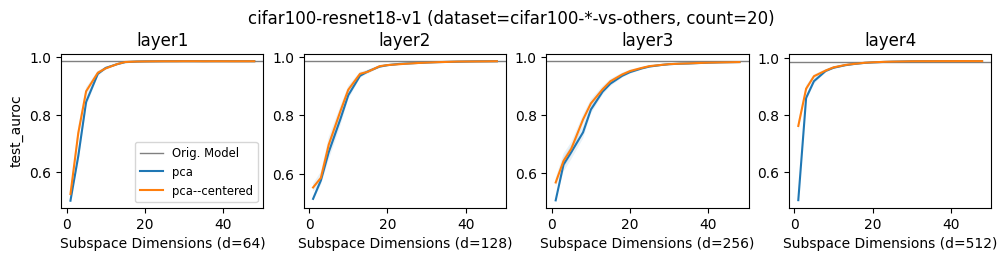

In [6]:
def alias(name):
    return name.replace("with-weight", "")
    # return {
    #     "prca-ablation-a-c": "prcaposdefv2",
    # }.get(name, name)
    
def viz(
    dataset_name="cifar100-people-vs-others",
    model_name="cifar100-resnet18-v1",
    arr_layers=["layer1", "layer2", "layer3", "layer4"], 
    arr_basis_names=[
        "pca",
        "gradpca",
        "prcaposdef",
        "prca-ablation-a-c",
        # "prcasortabs",
        # "prca",
    ],
    stat_col="test_auroc",
    ref_col="ref_auroc",
    dict_color_ls={
        "pca":        ("blue", "-"),
        "gradpca":    ("blue", "--"),
        "prcaposdef": ("red",  "-"),
        "prca-ablation-a-c": ("red",  "--"),
    }
):
    ncols = len(arr_layers)
    plt.figure(figsize=(3*ncols, 2))
    
    
   
    for lix, layer in enumerate(arr_layers):
        plt.subplot(1, ncols, lix + 1)
        plt.title(layer)
        for bix, basis_name in enumerate(arr_basis_names):
            df = load_data(
                model=model_name,
                layer=layer,
                # todo: we should aggregate this over several datasets
                dataset_name=dataset_name,
                basis_name=basis_name,
                ref_col=ref_col,
                stat_col=stat_col
            )
            if bix == 0:
                plt.axhline(df[ref_col]["mean"].values[-1], ls="-", color="gray", lw=1, label="Orig. Model")
                count = df[ref_col]["count"].values[-1]
                
            d = int(df.d["mean"].values[-1])
            div = 4
            max_k = 48
            selected = df.k <= max_k
            color, ls = dict_color_ls.get(basis_name, (None, None))

            arr_k = df["k"][selected]
            mean = df[stat_col]["mean"][selected]
            sem = df[stat_col]["sem"][selected]
            plt.plot(
                arr_k,
                mean,
                label=alias(basis_name),
                color=color,
                ls=ls,
                # marker=".",
            )
            plt.fill_between(
                arr_k,
                mean - sem,
                mean + sem,
                alpha=0.1,
                color=color
            )
            
        if lix == 0:
            plt.ylabel(stat_col)
            plt.legend(fontsize="small")
        
        plt.xlabel(f"Subspace Dimensions (d={d})")
    plt.suptitle(f"{model_name} (dataset={dataset_name}, count={count})", y=1.1)

viz(
    dataset_name="cifar100-*-vs-others", 
    arr_basis_names=[
        "pca", 
        # "gradpca",
        "pca--centered",
        # # "prcaposdef",
        # "prcaposdef--centered",
        # "prcaposdef-with-weight-p1",
        # "prcaposdef-with-weight-p1--centered"
    ],
    dict_color_ls={}
    #  dict_color_ls={
    #     "pca":        ("blue", "-"),
    #     "pca--centered":        ("blue", "--"),
    #     "gradpca":        ("gray", "-"),

    #     "prcaposdef": ("red",  "-"),
    #     "prcaposdef--centered": ("red",  "--"),
    # }
)

# CelebA

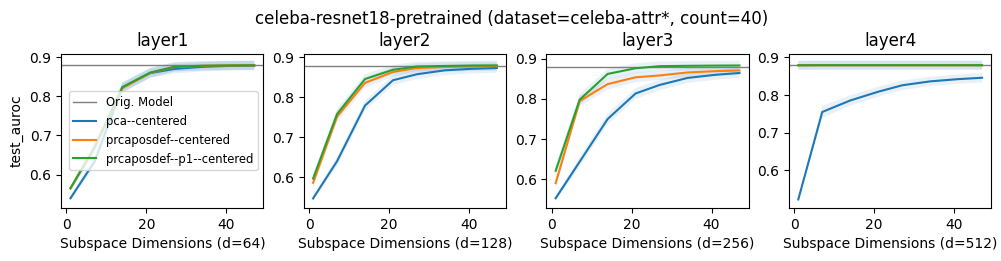

In [18]:
viz(
    dataset_name="celeba-attr*", 
    model_name="celeba-resnet18-pretrained",
    arr_basis_names=[
        # "pca", 
        # "gradpca",
        "pca--centered",
        # "prcaposdef",
        "prcaposdef--centered",
        # "prcaposdef-with-weight-p1",
        "prcaposdef-with-weight-p1--centered"
    ],
    dict_color_ls={}
    #  dict_color_ls={
    #     "pca":        ("blue", "-"),
    #     "pca--centered":        ("blue", "--"),
    #     "gradpca":        ("gray", "-"),

    #     "prcaposdef": ("red",  "-"),
    #     "prcaposdef--centered": ("red",  "--"),
    # }
)

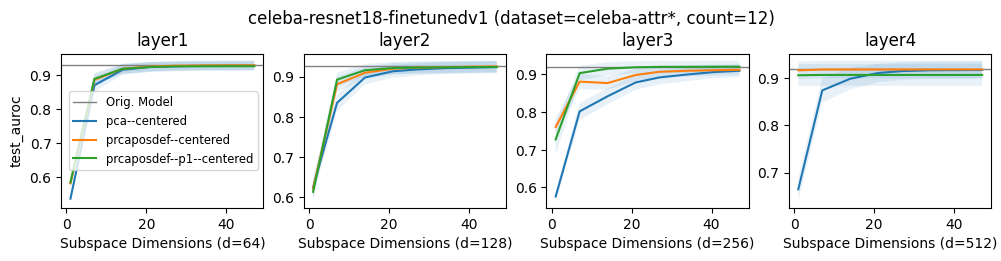

In [19]:
viz(
    dataset_name="celeba-attr*", 
    model_name="celeba-resnet18-finetunedv1",
    arr_basis_names=[
        # "pca", 
        # "gradpca",
        "pca--centered",
        # "prcaposdef",
        "prcaposdef--centered",
        # "prcaposdef-with-weight-p1",
        "prcaposdef-with-weight-p1--centered"
    ],
    dict_color_ls={}
    #  dict_color_ls={
    #     "pca":        ("blue", "-"),
    #     "pca--centered":        ("blue", "--"),
    #     "gradpca":        ("gray", "-"),

    #     "prcaposdef": ("red",  "-"),
    #     "prcaposdef--centered": ("red",  "--"),
    # }
)

In [16]:
raise

RuntimeError: No active exception to reraise